<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/04_Vector_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Vector Applications**

This notebook covers Vector Applications:
1. Correlation and Cosine Similarity
2. Time Series Filtering and Feature Detection
3. k-Means Clustering
4. Summary


## **1. Correlation and Cosine Similarity**

Correlation is one of the most fundamental analysis methods in statistics and machine learning. A correlation coefficient captures the *linear relationship* between two variables and ranges from −1 (perfect negative relationship) to +1 (perfect positive relationship), with 0 indicating no linear relationship.

In Chapter 2, Cohen mentioned that the dot product is related to the correlation coefficient. The full story is that the Pearson correlation coefficient is essentially the dot product between two *mean-centered* and *normalized* vectors. The two normalizations are:

1. Mean centering: Subtract the mean from each variable.
2. Normalize by the product of the vector norms: This cancels measurement units and scales the maximum correlation to |1|.

The formula for the Pearson correlation coefficient is:

$$\rho = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$$

In vector notation (where `x̃` and `ỹ` are mean-centered versions of x and y):

$$\rho = \frac{\tilde{\mathbf{x}}^T \tilde{\mathbf{y}}}{\|\tilde{\mathbf{x}}\| \|\tilde{\mathbf{y}}\|}$$

This is just three dot products! The numerator is the dot product of the mean-centered variables; the denominator is the product of their magnitudes.

### **1.1 Cosine Similarity**

Cosine similarity comes directly from the geometric definition of the dot product:

$$\cos(\theta_{x,y}) = \frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\| \|\mathbf{y}\|}$$

This looks almost identical to Pearson correlation — the difference is that cosine similarity does not mean-center the variables first. This distinction matters:

- Pearson correlation measures whether *changes* in one variable are mirrored by changes in another (mean-offset doesn't matter).
- Cosine similarity measures whether two vectors *point in the same direction* (magnitude scale matters, mean offset does not get removed).

For example, vectors [0, 1, 2, 3] and [100, 101, 102, 103] have a Pearson correlation of 1.0 (perfectly linearly related) but a cosine similarity of ~0.808 (they don't point in the same direction because of the offset).

In [1]:
import numpy as np

# Implement Pearson correlation and cosine similarity from scratch
def pearson_correlation(x, y):
    """Compute Pearson correlation coefficient between two vectors."""
    x_mc = x - np.mean(x)  # mean center
    y_mc = y - np.mean(y)
    numerator   = np.dot(x_mc, y_mc)
    denominator = np.linalg.norm(x_mc) * np.linalg.norm(y_mc)
    return numerator / denominator

def cosine_similarity(x, y):
    """Compute cosine similarity between two vectors."""
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

# Test with mean-centered variables: both measures should agree
x = np.array([1.0, 2, 3, 4, 5])
y = np.array([2.0, 4, 5, 4, 5])

print(f'Pearson correlation:    {pearson_correlation(x, y):.4f}')
print(f'Cosine similarity:      {cosine_similarity(x, y):.4f}')
print(f'NumPy corrcoef:         {np.corrcoef(x, y)[0,1]:.4f}')

# Test with non-mean-centered variables: measures should diverge
x2 = np.array([0, 1, 2, 3], dtype=float)
y2 = x2 + 100  # same relationship, but large offset

print(f'\nWith offset +100:')
print(f'Pearson correlation:    {pearson_correlation(x2, y2):.4f}')  # should be 1.0
print(f'Cosine similarity:      {cosine_similarity(x2, y2):.4f}')   # should be ~0.808

Pearson correlation:    0.7746
Cosine similarity:      0.9597
NumPy corrcoef:         0.7746

With offset +100:
Pearson correlation:    1.0000
Cosine similarity:      0.8083


## **2. Time Series Filtering and Feature Detection**

The dot product is at the heart of time series filtering, which is a method for *detecting features* in a signal. The idea is elegant: you design a short template vector called a kernel that captures the shape of the feature you want to detect (e.g., a sharp edge, a smooth bump, a specific waveform). Then you slide that kernel across the signal, computing the dot product between the kernel and each overlapping segment of the signal.

When the signal segment closely matches the kernel shape, the dot product is large. When the segment is dissimilar to the kernel, the dot product is near zero. The output is a new time series indicating *where* and *how strongly* the target feature appears.

This procedure is the mathematical foundation of convolution (a few additional steps are needed for full convolution, but the dot product is the core mechanism). Without this operation, there would be no digital music, no radio, no telecommunications, no imaging systems.

Cohen illustrates two cases:

- Edge detection kernel `[-1, +1]`: returns 0 for flat signal segments, positive where the signal jumps up, negative where it drops.
- Gaussian smoothing kernel: a bell-shaped function that averages out rapid fluctuations, producing a smoother version of the signal.

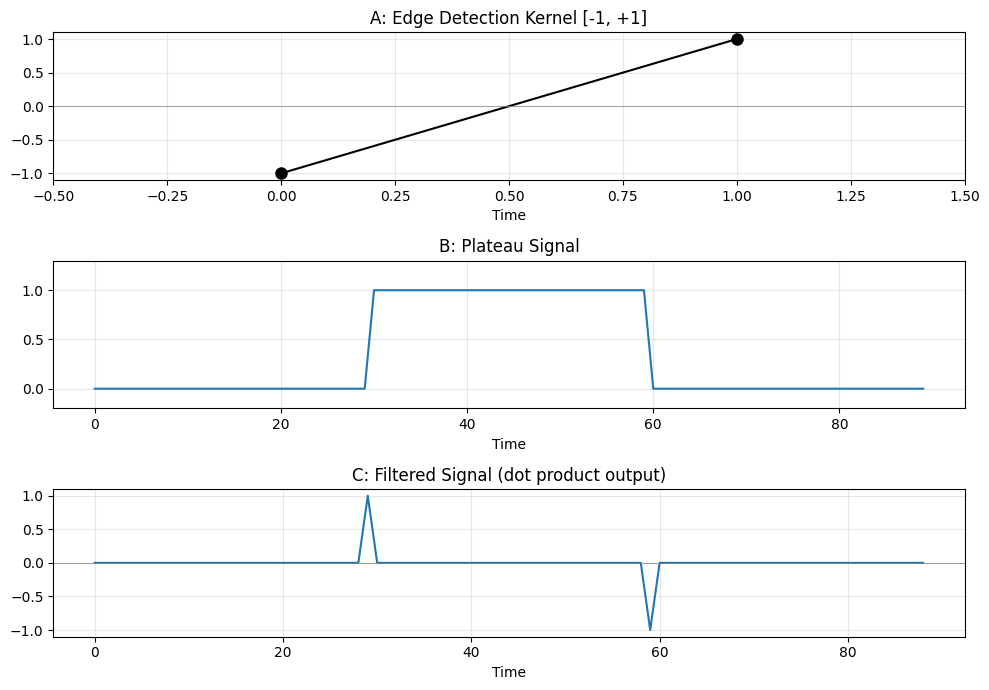

In [2]:
import matplotlib.pyplot as plt
# Time series filtering: edge detection

# Create a plateau signal: 0 for the first third, 1 for the middle, 0 for the last third
n = 90
signal = np.zeros(n)
signal[n//3 : 2*n//3] = 1

# Edge-detection kernel
kernel = np.array([-1, 1])

# Slide the kernel across the signal and compute dot products
k = len(kernel)
filtered = np.zeros(n - k + 1)
for i in range(len(filtered)):
    filtered[i] = np.dot(kernel, signal[i : i + k])

# Plot
fig, axes = plt.subplots(3, 1, figsize=(10, 7))

axes[0].plot(kernel, 'ko-', ms=8)
axes[0].set_title('A: Edge Detection Kernel [-1, +1]')
axes[0].set_xlim(-0.5, 1.5)
axes[0].axhline(0, color='gray', lw=0.5)

axes[1].plot(signal)
axes[1].set_title('B: Plateau Signal')
axes[1].set_ylim(-0.2, 1.3)

axes[2].plot(filtered)
axes[2].set_title('C: Filtered Signal (dot product output)')
axes[2].axhline(0, color='gray', lw=0.5)

for ax in axes:
    ax.set_xlabel('Time')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

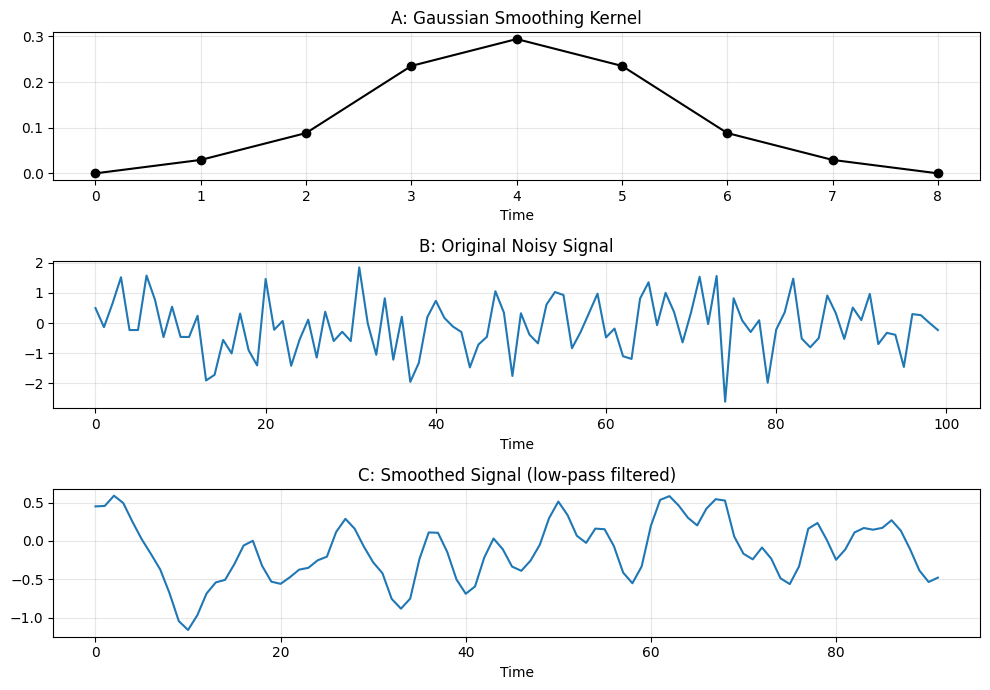

In [3]:
# Gaussian smoothing kernel

# Create a random signal
np.random.seed(42)
signal_noisy = np.random.randn(100)

# Bell-shaped Gaussian kernel
kernel_gauss = np.array([0, 0.1, 0.3, 0.8, 1, 0.8, 0.3, 0.1, 0])
kernel_gauss = kernel_gauss / np.sum(kernel_gauss)  # normalize so sum = 1

k = len(kernel_gauss)
smoothed = np.zeros(len(signal_noisy) - k + 1)
for i in range(len(smoothed)):
    smoothed[i] = np.dot(kernel_gauss, signal_noisy[i : i + k])

fig, axes = plt.subplots(3, 1, figsize=(10, 7))

axes[0].plot(kernel_gauss, 'ko-')
axes[0].set_title('A: Gaussian Smoothing Kernel')

axes[1].plot(signal_noisy)
axes[1].set_title('B: Original Noisy Signal')

axes[2].plot(smoothed)
axes[2].set_title('C: Smoothed Signal (low-pass filtered)')

for ax in axes:
    ax.set_xlabel('Time')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **3. k-Means Clustering**

k-means clustering is a fundamental unsupervised machine learning algorithm for grouping multivariate data into a predefined number of clusters based on minimizing distance to cluster centers (centroids).

Cohen uses this algorithm to show how vector norms and broadcasting — concepts introduced in Chapters 2 and 3 — work together in a practical setting. The algorithm is beautifully simple:

1. Initialize `k` random cluster centroids by randomly selecting `k` data points.
2. Compute distances between each data point and each centroid (using squared Euclidean distance).
3. Assign each data point to its closest centroid.
 Update each centroid as the mean of all points assigned to it.
5. Repeat steps 2–4 until convergence (or for a fixed number of iterations).

### **3.1 Key Linear Algebra Insight: Broadcasting**

The distance computation is where linear algebra shines. Rather than using a double for loop (one over data points and one over centroids), broadcasting allows us to subtract a centroid from *all* data points simultaneously.


`data` is 150×2, `centroids[ci,:]` is 1×2. Broadcasting repeats the centroid 150 times, subtracts element-wise, squares, and sums across features — computing all 150 distances in one line.

Note: we omit the square root (computing squared distance instead of Euclidean distance). This is valid because for the purpose of *finding the nearest centroid*, squared distance and Euclidean distance give the same ordering — and the square root is computationally expensive with no benefit for this particular application.

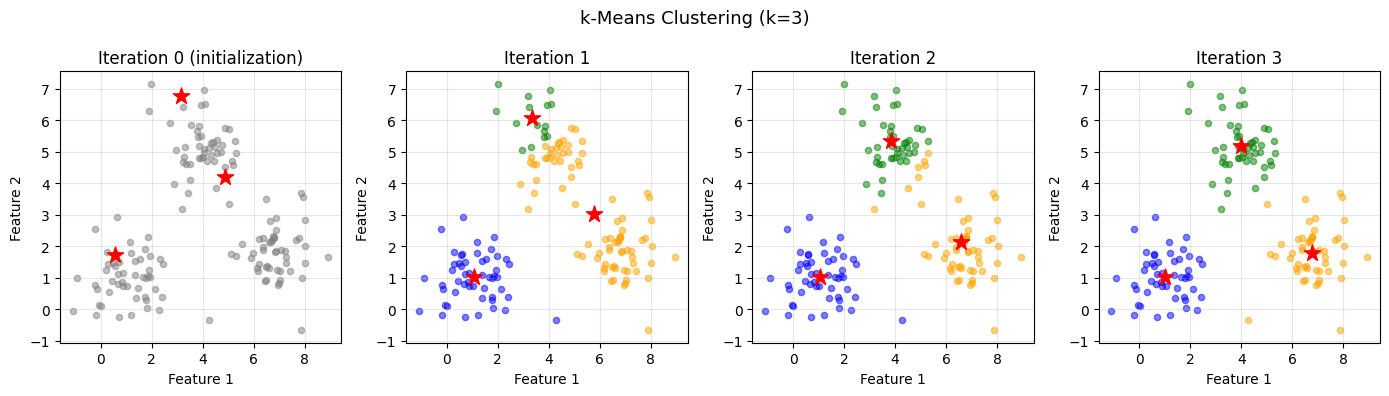

In [4]:
# k-Means Clustering from scratch using vectors and broadcasting

# Generate synthetic 2D data with three natural clusters
np.random.seed(2024)
cluster_centers = np.array([[1, 1], [4, 5], [7, 2]])
n_per_cluster   = 50
data = np.vstack([
    center + np.random.randn(n_per_cluster, 2) * 0.8
    for center in cluster_centers
])

# --- k-Means Algorithm ---
k = 3
n_iterations = 3

# Step 1: Initialize k random centroids
ridx = np.random.choice(range(len(data)), k, replace=False)
centroids = data[ridx, :].copy()

fig, axes = plt.subplots(1, n_iterations + 1, figsize=(14, 4))

# Plot initial state
axes[0].scatter(data[:, 0], data[:, 1], c='gray', alpha=0.5, s=20)
axes[0].scatter(centroids[:, 0], centroids[:, 1], c='red', s=150, marker='*', zorder=5)
axes[0].set_title('Iteration 0 (initialization)')

colors = ['blue', 'orange', 'green']

for iteration in range(n_iterations):
    # Step 2: Compute squared Euclidean distances to all centroids
    dists = np.zeros((data.shape[0], k))
    for ci in range(k):
        dists[:, ci] = np.sum((data - centroids[ci, :])**2, axis=1)

    # Step 3: Assign each point to the nearest centroid
    groupidx = np.argmin(dists, axis=1)

    # Step 4: Update centroids as mean of assigned points
    for ki in range(k):
        centroids[ki, :] = [np.mean(data[groupidx == ki, 0]),
                             np.mean(data[groupidx == ki, 1])]

    # Plot current state
    ax = axes[iteration + 1]
    for ki in range(k):
        mask = groupidx == ki
        ax.scatter(data[mask, 0], data[mask, 1], c=colors[ki], alpha=0.5, s=20)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=150, marker='*', zorder=5)
    ax.set_title(f'Iteration {iteration + 1}')

for ax in axes:
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('k-Means Clustering (k=3)', fontsize=13)
plt.tight_layout()
plt.show()

## **4. Summary**

Chapter 4 demonstrates that the seemingly abstract operations introduced in Chapters 2 and 3 are not purely theoretical — they are the engines of widely used, practical data science methods:

- Pearson correlation is three dot products combined with mean centering and magnitude normalization. It measures linear co-variation between variables.
- Cosine similarity is the geometric form of the dot product, measuring the angular relationship between vectors without mean centering.
- Time series filtering uses the dot product to compute sliding similarity between a kernel template and a signal — the foundation of convolution and signal processing.
- k-Means clustering uses vector distances, broadcasting, and vector averaging to iteratively discover cluster structure in multivariate data.

All three applications rely on the same small set of vector operations: the dot product, vector norms, and element-wise arithmetic. The power of linear algebra lies not in the complexity of individual operations, but in how these simple operations compose to produce powerful algorithms.